In [2]:
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import pandas as pd

### Project 5: Dirac Equation -- Conrad and Ivan

In [3]:
c=137.036
hbar=m=e=1

def ddxmatrix(dim,step): #this is the central difference derivative matrix it has a -1 to the left of diagonal and 1 to the right
    out = np.zeros((dim,dim))
    out[0][1]=8
    out[-1][-2] =-8
    out[0][2]=out[1][3]=-1
    out[-1][-3]=out[-2][-4] =1
    for i in range(1,dim-1):
        out[i][i-1]=-8
        out[i][i+1]=8
    for i in range (2,dim-2):
        out[i][i-2]=1
        out[i][i+2]=-1
    out = out/(12*step)#division by 2h from formula
    return out
"""

def ddxmatrix(dim,step): #this is the central difference derivative matrix it has a -1 to the left of diagonal and 1 to the right
    out = np.zeros((dim,dim))
    out[0][1]=1
    out[-1][-2] =-1
    for i in range(1,dim-1):
        out[i][i-1]=-1
        out[i][i+1]=1
    out = out/(2*step)#division by 2h from formula
    return out
"""

def createpot(n,step,Z): #creates couloumb potential for given nuclear charge z, note k =1 in au
    out = np.zeros((n,n))
    for i in range(len(out)):
        out[i][i]= -Z/((i+1)*step)
    return out

def createtopright(n,step,k): #creates top left nxn component
    out = ddxmatrix(n,step)
    for i in range(0,n):
        out[i][i]=out[i][i]-k/((1+i)*step)
    out= c * out
    return out

def createbottomleft(n,step,k): #creates bottom left nxn component
    out = ddxmatrix(n,step)
    for i in range(0,n):
        out[i][i]=out[i][i]+k/((1+i)*step)
    out= -c*out
    return out

def createtopleft(n,step,Z): #creates top left nxn component
    out = createpot(n,step,Z)
    out = out +np.diag(np.full(n,c**2))
    return out

def createbottomright(n,step,Z): #creates top left nxn component
    out = createpot(n,step,Z)
    out = out -np.diag(np.full(n,c**2))
    return out

def createhamiltonian(n,step,Z,k):
    right = np.vstack((createtopright(n,step,k),createbottomright(n,step,Z)))
    left = np.vstack((createtopleft(n,step,Z),createbottomleft(n,step,k)))
    out = np.hstack((left,right))
    return out







In [4]:
# Verifications of properties:
# 1
n = 6501
rmax = 150
step = rmax/n
r = np.array([(i+1)*step for i in range(n)])

H = createhamiltonian(n, step, 1, -1)

asymmetry = np.max(np.abs(H - H.T))
print("max of H - H.T is", asymmetry)

# we want this to be 0 for the hamiltonian to be hermitian

max of H - H.T is 0.0


In [5]:
#2

# This code prints the bound state energies 
evals, evecs = np.linalg.eigh(H)
max_imag = np.max(np.abs(evals.imag))
print("max imaginary part is", max_imag)
evals = evals.real

order = np.argsort(evals)
evals = evals[order]
evecs = evecs[:, order]

shifted = evals - c**2 # we want this to be negative for bound states, and positive for scattering states because the rest mass energy is c^2 in au, so energies below that correspond to bound states and above correspond to scattering states
bound_mask = (shifted < 0) & (shifted > -1.0)
bound_energies = shifted[bound_mask]
bound_vecs = evecs[:, bound_mask]

print("bound state energies:")
for E in bound_energies:
    print(E)
print()
    


max imaginary part is 0.0
bound state energies:
-0.5000065077547333
-0.12500224440009333
-0.07032068701300886
-0.05555634519259911
-0.03125036587880459
-0.02662948236320517
-0.02000019386105123
-0.013890693142457167
-0.013888114193832735
-0.010204202430031728
-0.00852220950400806
-0.007804043012583861
-0.006227771664271131
-0.005002398720534984
-0.0032608443980279844
-0.0012407151771185454



In [6]:

def check_spurious(evec, max_crossing): #tests if an eigenvector is spurious by counting zero crossings and comparing to max allowed value
    count = 0
    absmax=np.max(abs(evec))
    testrange = len(evec)//40 

    for i in range(testrange,len(evec)-testrange):
        if evec[i]*evec[i+1] <0 and np.max(np.abs(evec[i-testrange:i+testrange])>absmax/5): #we need the second requirement as near zero the function constantly swaps sign
            count +=1
    return count >= max_crossing

for i in range(np.shape(bound_vecs)[1]):
    if check_spurious(bound_vecs[:,i],100):
        print(f"State {i+1} is potentially spurious")

State 3 is potentially spurious
State 6 is potentially spurious
State 8 is potentially spurious
State 9 is potentially spurious
State 11 is potentially spurious
State 12 is potentially spurious
State 13 is potentially spurious
State 14 is potentially spurious
State 15 is potentially spurious
State 16 is potentially spurious


In [7]:
#bound energy error and removing spurious solutions
spurious_mask = []
for i in range(np.shape(bound_vecs)[1]):
        spurious_mask.append(not check_spurious(bound_vecs[:,i],100))
spurious_mask = np.array(spurious_mask)
test = bound_energies[spurious_mask]
print(test)

[-0.50000651 -0.12500224 -0.05555635 -0.03125037 -0.02000019 -0.0102042 ]


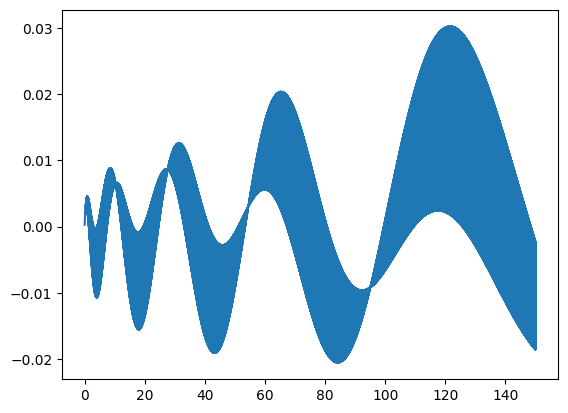

In [8]:
plt.plot(np.linspace(step, rmax,n),bound_vecs[:n,13])

In [9]:
#3 this code compares the bound state energies to the exact values for a point nucleus, which are given by the formula below. 

alpha = 1/c
def exact_E(nn, kk, Z=1):
    gamma = np.sqrt(kk**2 - (Z*alpha)**2)
    denom = np.sqrt(1 + (Z*alpha/(nn - abs(kk) + gamma))**2)
    return c**2/denom - c**2

print("n, extent n^2 bohr, exact E - c^2:")
for nn in range(1, 16):
    print(nn, nn**2, exact_E(nn, -1))
print()
print("rmax is", rmax, "bohr")
print()


n, extent n^2 bohr, exact E - c^2:
1 1 -0.5000066565953603
2 4 -0.12500208018900594
3 9 -0.05555629517766647
4 16 -0.03125033803007682
5 25 -0.020000181059003808
6 36 -0.013888996749301441
7 49 -0.01020415094535565
8 64 -0.007812547130015446
9 81 -0.006172872985189315
10 100 -0.005000024630135158
11 121 -0.00413225004740525
12 144 -0.003472236669040285
13 169 -0.0029585912998300046
14 196 -0.002551029589085374
15 225 -0.0022222297156986315

rmax is 150 bohr



In [10]:
#4
E_2p12 = exact_E(2, +1)   # 2p_1/2 has kappa = +1
E_2p32 = exact_E(2, -2)   # 2p_3/2 has kappa = -2
splitting = E_2p32 - E_2p12
print("2p_1/2 energy:", E_2p12)
print("2p_3/2 energy:", E_2p32)
print("splitting:", splitting)

2p_1/2 energy: -0.12500208018900594
2p_3/2 energy: -0.12500041602834244
splitting: 1.6641606634948403e-06


In [11]:
#normalization of eigenvectors

def simpsons_integral(y, dx): #this is our code from project 2
    sum1=0
    sum2=0
    for i in range(len(y)//2):
      sum1 += y[2*i+1]
    for i in range(len(y)//2-1):
      sum2 += y[2*i+2]

    integral = dx/3*(y[0]+4*sum1+2*sum2+y[-1]) # -1*y[0] accounts for fact sum1 has a 2y[0] involved"""

    return integral

def simpsons_integraln(y,dx):
    if len(y) %2 ==0:
      print("warning, even vector size")
    sum = y[0] +y[-1]
    for i in range(1,len(y)-1):
      if (i%2)==0:
        sum+= 2*y[i]
      else:
        sum += 4*y[i]
    sum = sum*dx/3
    return sum




evecs_normalized = np.zeros_like(bound_vecs)
for i in range(np.shape(bound_vecs)[1]):
  ce = bound_vecs[:,i]#current evector
  g=ce[:n]
  f=ce[n:]
  r= g*np.conj(g)+f*np.conj(f)
  co = 1/np.sqrt(simpsons_integraln(r,step)) #constant needed to normalize evector
  ce = ce*co
  evecs_normalized[:,i] = ce





In [34]:
#uncertainty principle
#testing for n = 1 expectation for x

def ddx2matrix(dim,step):#central difference matrix for second derivative
    out = np.zeros((dim,dim))
    out[0,0]=-2
    out[0,1]=1 
    out[-1,-1]=-2
    out[-1,-2]=1
    for i in range(1,dim-1):
        out[i,i-1]=1
        out[i,i]=-2
        out[i,i+1]=1
    out = out/(step**2)
    return out

x_op = np.diag(np.linspace(step, rmax,n))
x2_op = x_op*x_op
p_op = -1j *ddxmatrix(n,step)
p2_op = -1 *ddx2matrix(n,step)
def expt(eindex,operator): #finds expectation of x for nth eigenvalue with given operator(which is matrix)
  g = evecs_normalized[:n,eindex]
  f = evecs_normalized[n:,eindex]
  addend_g = np.conj(g) * (operator@g)
  addend_f = np.conj(f) * (operator@f)
  return(np.sum(addend_f+addend_g)*step)

def unc(a,b):
  return np.sqrt(a-b**2)

for i in range(len(evecs_normalized[1])):

  expx = expt(i,x_op)
  expx2 = (expt(i,x2_op))
  expp = abs(expt(i,p_op))
  expp2 = expt(i,p2_op)
  uncx= unc(expx2,expx)
  uncp= unc(expp2,expp)
  print(f"""Expectation for x is {expx}\n
  Expectation for x^2 is {expx2}""")


Expectation for x is 1.5176226200908332

  Expectation for x^2 is 3.035426431489625
Expectation for x is 5.972402999740675

  Expectation for x^2 is 41.79188867193334
Expectation for x is 9.374633243524366

  Expectation for x^2 is 107.8808680529879
Expectation for x is 13.385758937115412

  Expectation for x^2 is 205.20075560366155
Expectation for x is 24.201420697037822

  Expectation for x^2 is 653.2618846256712
Expectation for x is 26.49617970577845

  Expectation for x^2 is 819.6554190659375
Expectation for x is 37.68249144168687

  Expectation for x^2 is 1582.388593658813
Expectation for x is 44.663274345769565

  Expectation for x^2 is 2666.1262187425955
Expectation for x is 65.71643301034749

  Expectation for x^2 is 3958.55688230606
Expectation for x is 73.14935834714557

  Expectation for x^2 is 5997.408499107701
Expectation for x is 87.38681333145311

  Expectation for x^2 is 8522.132415257222
Expectation for x is 95.30928654720947

  Expectation for x^2 is 10197.10843502253

/tmp/ipykernel_63813/1867382010.py:29: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(a-b**2)


Expectation for x is 128.11437349952558

  Expectation for x^2 is 18539.050021600186
Expectation for x is 150.66247165051567

  Expectation for x^2 is 25158.969519438564
Expectation for x is 219.01138282991135

  Expectation for x^2 is 44938.02298940923
Expectation for x is 155.54944648155882

  Expectation for x^2 is 30882.23097775154
Expectation for x is 247.49925852693872

  Expectation for x^2 is 58990.99230459764
Expectation for x is 205.74260282727496

  Expectation for x^2 is 48664.88040654136
Expectation for x is 193.22277004450365

  Expectation for x^2 is 42777.089527166434
Expectation for x is 204.23775599610389

  Expectation for x^2 is 45903.54619289149
Expectation for x is 173.54757860871555

  Expectation for x^2 is 37732.31828070719
Expectation for x is 192.3643237251054

  Expectation for x^2 is 41504.72101264892


In [12]:
#convergence testing



#energy expectations for n=100-n=3000


E10_list = []
E2_list = []
n_list = []

r_list=[]
veccount_list = []

for i in range (20):
    rmaxt=np.round(1.15**i*30)
    nt=2001
    stept = rmaxt/nt
    Ht = createhamiltonian(nt, stept, 1, -1)
    evalst = np.linalg.eigvalsh(Ht)

    evalst = evalst.real

    ordert = np.argsort(evalst)

    evalst = evalst[ordert]

    shiftedt = evalst - c**2

    bound_maskt = (shiftedt < 0) & (shiftedt > -1.0)
    bound_energiest = shiftedt[bound_maskt]
    veccount_list.append(len(bound_energiest))
    r_list.append(rmaxt)
    

"""
for i in range(17):
  nt = 100+ np.round(1.5**i*10)
  if nt %2 ==0:
    nt+=1
  rmaxt = 150
  stept = rmaxt/nt
  print(nt)
  nt = int(nt)
  Ht = createhamiltonian(nt, stept, 1, -1)
  evalst = np.linalg.eigvalsh(Ht)

  evalst = evalst.real

  ordert = np.argsort(evalst)

  evalst = evalst[ordert]

  shiftedt = evalst - c**2

  bound_maskt = (shiftedt < 0) & (shiftedt > -1.0)
  bound_energiest = shiftedt[bound_maskt]
  E10_list.append(bound_energiest[13])
  

  n_list.append(nt)

"""

'\nfor i in range(17):\n  nt = 100+ np.round(1.5**i*10)\n  if nt %2 ==0:\n    nt+=1\n  rmaxt = 150\n  stept = rmaxt/nt\n  print(nt)\n  nt = int(nt)\n  Ht = createhamiltonian(nt, stept, 1, -1)\n  evalst = np.linalg.eigvalsh(Ht)\n\n  evalst = evalst.real\n\n  ordert = np.argsort(evalst)\n\n  evalst = evalst[ordert]\n\n  shiftedt = evalst - c**2\n\n  bound_maskt = (shiftedt < 0) & (shiftedt > -1.0)\n  bound_energiest = shiftedt[bound_maskt]\n  E10_list.append(bound_energiest[13])\n\n\n  n_list.append(nt)\n\n'

[np.float64(30.0), np.float64(34.0), np.float64(40.0), np.float64(46.0), np.float64(52.0), np.float64(60.0), np.float64(69.0), np.float64(80.0), np.float64(92.0), np.float64(106.0), np.float64(121.0), np.float64(140.0), np.float64(161.0), np.float64(185.0), np.float64(212.0), np.float64(244.0), np.float64(281.0), np.float64(323.0), np.float64(371.0), np.float64(427.0)]
[6, 7, 8, 8, 9, 10, 10, 11, 12, 13, 14, 15, 17, 18, 19, 21, 23, 24, 26, 28]
[]
[np.float64(30.0), np.float64(34.0), np.float64(40.0), np.float64(46.0), np.float64(52.0), np.float64(60.0), np.float64(69.0), np.float64(80.0), np.float64(92.0), np.float64(106.0), np.float64(121.0), np.float64(140.0), np.float64(161.0), np.float64(185.0), np.float64(212.0), np.float64(244.0), np.float64(281.0), np.float64(323.0), np.float64(371.0), np.float64(427.0)]
[6, 7, 8, 8, 9, 10, 10, 11, 12, 13, 14, 15, 17, 18, 19, 21, 23, 24, 26, 28]


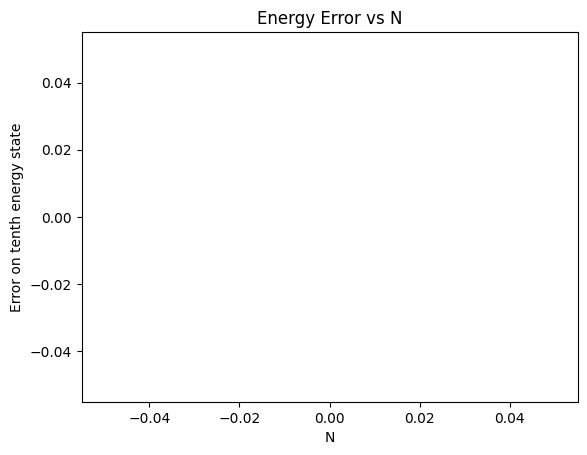

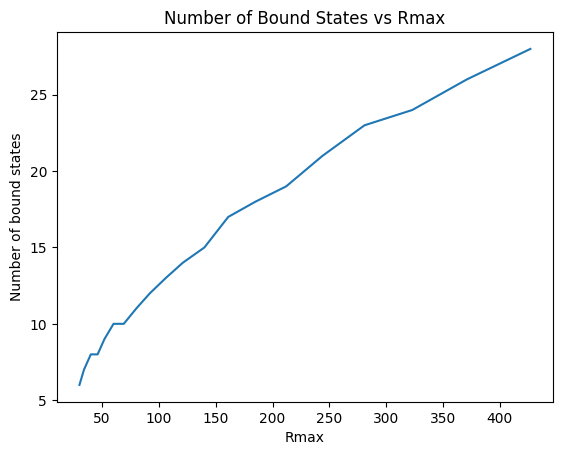

In [14]:
#convergence graphing 
error_list = np.full_like(E10_list,-0.005000024630135158)
print(r_list)
print(veccount_list)
plt.figure()
plt.title("Energy Error vs N")
plt.xlabel("N")
plt.ylabel("Error on tenth energy state")
plt.plot(n_list, np.abs(E10_list-error_list))
print(E10_list)



error_list = np.full_like(E10_list,-0.005000024630135158)
print(r_list)
print(veccount_list)
plt.figure()
plt.title("Number of Bound States vs Rmax")
plt.xlabel("Rmax")
plt.ylabel("Number of bound states")
plt.plot(r_list, veccount_list)


Found 16 states for κ=-1, 16 states for κ=+1


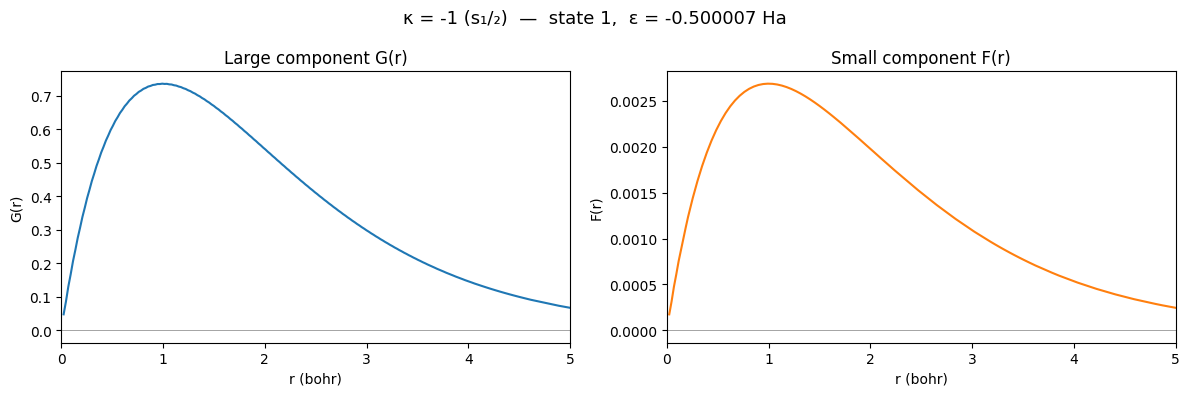

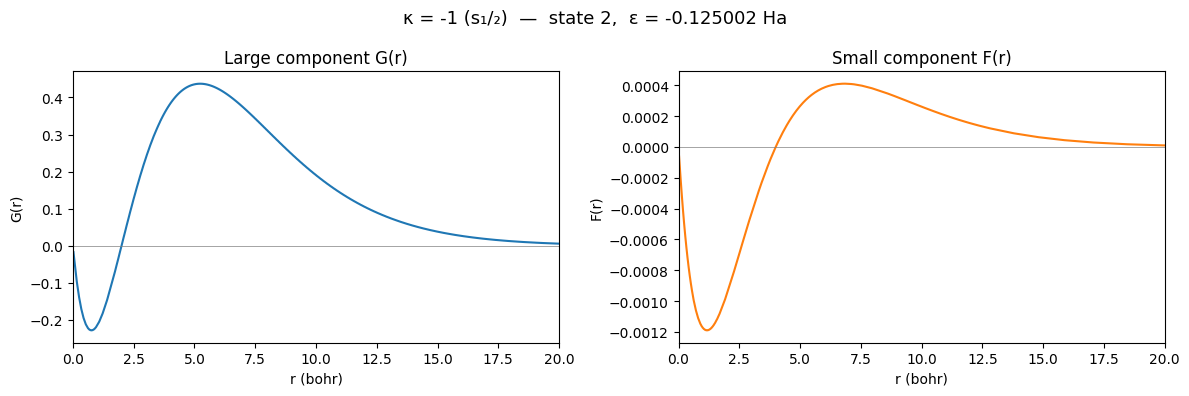

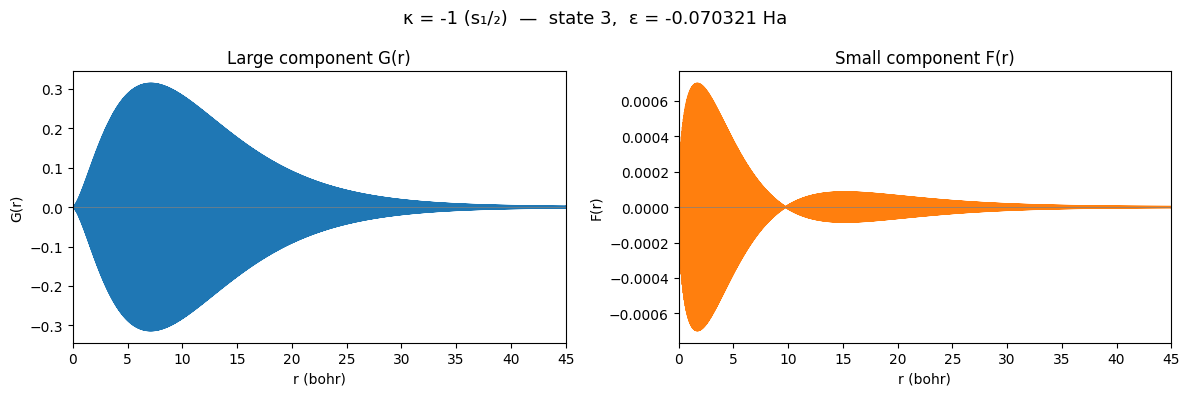

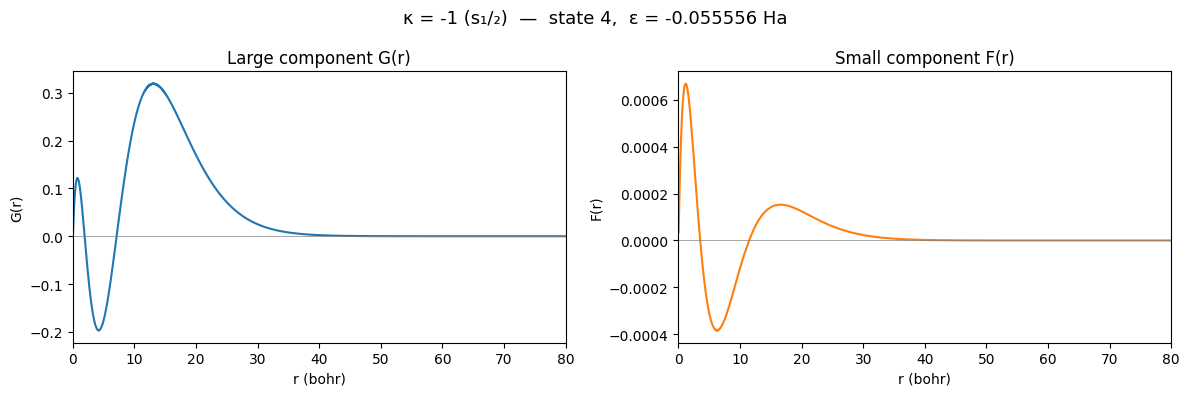

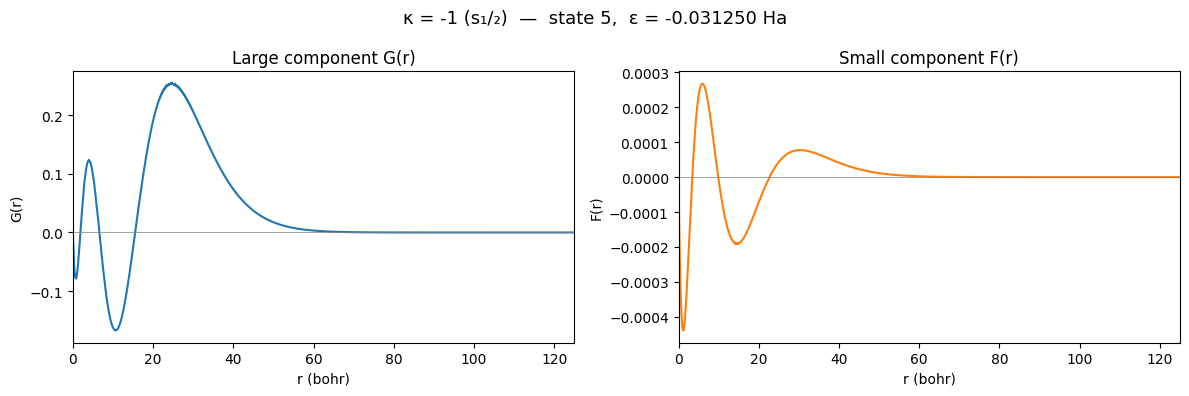

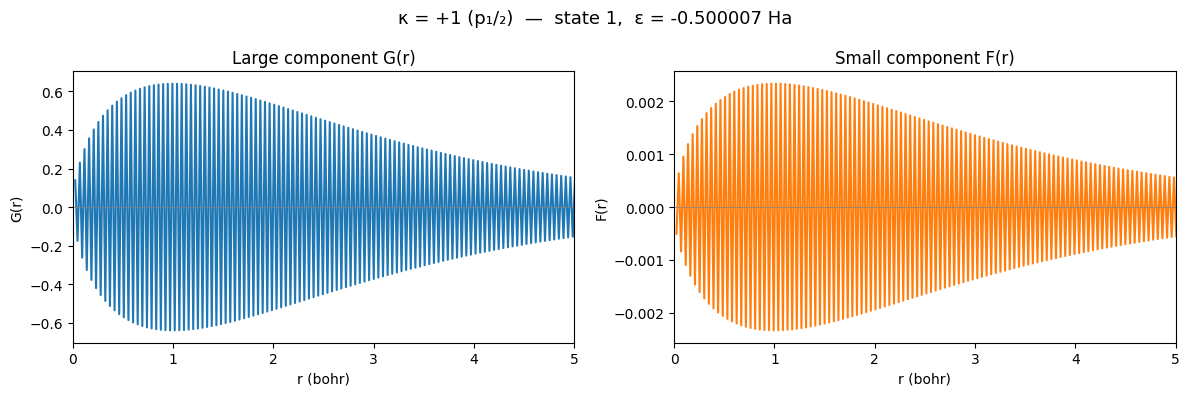

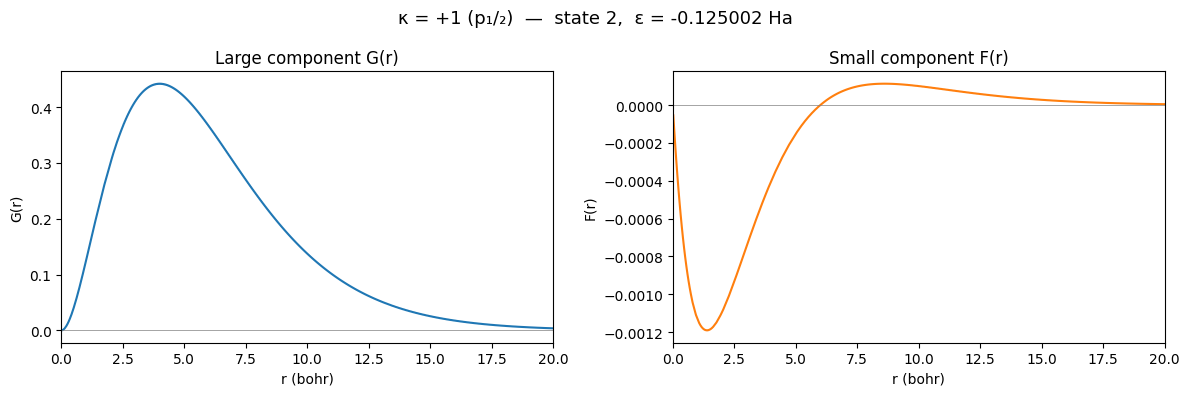

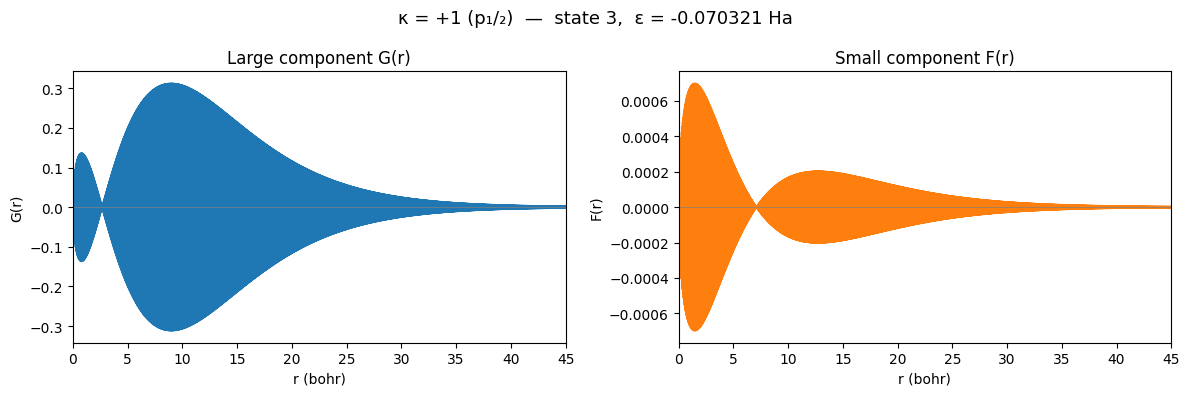

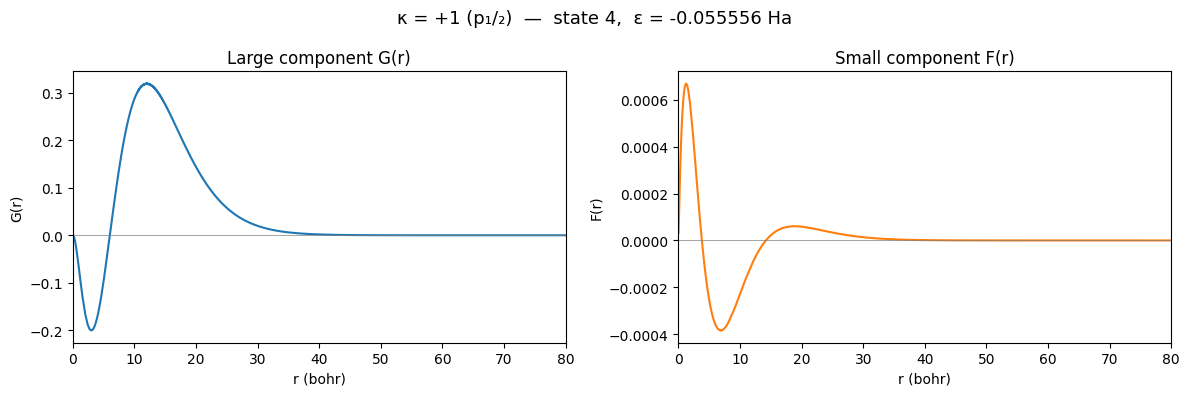

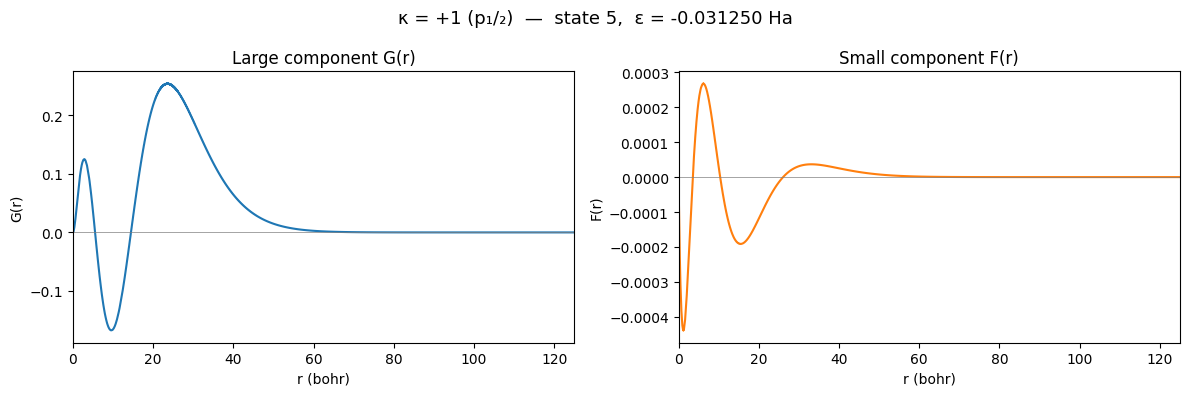

In [13]:
# Plot G(r) and F(r) for multiple bound states, for κ=-1 and κ=+1
# κ=-1 data reused from cells 4-8 (evecs_normalized, bound_energies)
# κ=+1 computed fresh here

r_grid = np.array([(i+1)*step for i in range(n)])

H_kp1 = createhamiltonian(n, step, 1, +1)
evals_kp1, evecs_kp1 = np.linalg.eigh(H_kp1)
evals_kp1 = evals_kp1.real
order_kp1 = np.argsort(evals_kp1)
evals_kp1 = evals_kp1[order_kp1]
evecs_kp1 = evecs_kp1[:, order_kp1]

shifted_kp1 = evals_kp1 - c**2
mask_kp1 = (shifted_kp1 < 0) & (shifted_kp1 > -1.0)
bound_energies_kp1 = shifted_kp1[mask_kp1]
bound_vecs_kp1 = evecs_kp1[:, mask_kp1]

evecs_norm_kp1 = np.zeros_like(bound_vecs_kp1)
for i in range(bound_vecs_kp1.shape[1]):
    ce = bound_vecs_kp1[:, i]
    g = ce[:n]; f = ce[n:]
    rho = (g * np.conj(g) + f * np.conj(f)).real
    co = 1 / np.sqrt(simpsons_integraln(rho, step))
    evecs_norm_kp1[:, i] = ce * co

print(f"Found {len(bound_energies)} states for κ=-1, {len(bound_energies_kp1)} states for κ=+1")

datasets = [
    ("κ = -1 (s₁/₂)", evecs_normalized, bound_energies),
    ("κ = +1 (p₁/₂)", evecs_norm_kp1, bound_energies_kp1),
]

max_states = 5

for label, vecs, energies in datasets:
    n_plot = min(max_states, vecs.shape[1])
    for i in range(n_plot):
        g = vecs[:n, i].real
        f = vecs[n:, i].real
        if g[np.argmax(np.abs(g))] < 0:
            g = -g
            f = -f

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.plot(r_grid, g, color='tab:blue')
        ax1.set_ylabel('G(r)')
        ax1.set_xlabel('r (bohr)')
        ax1.set_title('Large component G(r)')
        ax1.set_xlim(0, (i+1)**2 * 5)
        ax1.axhline(0, color='gray', lw=0.5)

        ax2.plot(r_grid, f, color='tab:orange')
        ax2.set_ylabel('F(r)')
        ax2.set_xlabel('r (bohr)')
        ax2.set_title('Small component F(r)')
        ax2.set_xlim(0, (i+1)**2 * 5)
        ax2.axhline(0, color='gray', lw=0.5)

        fig.suptitle(f'{label}  —  state {i+1},  ε = {energies[i]:.6f} Ha', fontsize=13)
        plt.tight_layout()
        plt.show()

In [ ]:
#expectations and uncertainty in a table with pandas

import pandas as pd
from IPython.display import display

x_list = []
x2_list = []
p_list = []
p2_list = []
xu_list = []
pu_list = []
h_list = []

for i in range(np.shape(evecs_normalized)[1]):



  expx=expt(i,x_op)
  expx2=expt(i,x2_op)
  expp=expt(i,p_op)
  expp2=expt(i,p2_op)
  uncx= unc(expx2,expx)
  uncp= unc(expp2,expp)

  x_list.append(expx)
  x2_list.append(expx2)
  p_list.append(expp)
  p2_list.append(expp2)
  uncproduct = uncx*uncp
  xu_list.append(uncx)
  pu_list.append(uncp)
  h_list.append(uncproduct)





df = pd.DataFrame({
  "x expectation": x_list,
  "x^2 expectation": x2_list,
  "p expectation": p_list,
  "p^2 expectation": p2_list,
  "x uncertainty": xu_list,
  "p uncertainty": pu_list,
  "product of uncertainties": h_list})
df = df.round(3)
df = np.real(df)
df.loc




[:, :] = np.real(df)
display(df)

NameError: name 'expt' is not defined

## Phase 2 -- Commented ;)

In [16]:
alpha = 1 / 137.035999084
c = 1 / alpha

def exact_E_dirac(nn, kk, Z):
    gamma = np.sqrt(kk**2 - (Z * alpha)**2)
    denom = np.sqrt(1 + (Z * alpha / (nn - abs(kk) + gamma))**2)
    return c**2 / denom - c**2

def compute_fine_structure(Z, N=2000, t_min=np.log(1e-6), t_max=np.log(60.0)):
    t = np.linspace(t_min, t_max, N)
    dt = t[1] - t[0]
    r = np.exp(t)
    V = -Z / r

    D_t = np.zeros((N, N))
    for i in range(2, N - 2):
        D_t[i, i-2] =  1 / (12 * dt)
        D_t[i, i-1] = -8 / (12 * dt)
        D_t[i, i+1] =  8 / (12 * dt)
        D_t[i, i+2] = -1 / (12 * dt)

    inv_r = np.diag(1.0 / r)
    half_inv_r = np.diag(1.0 / (2 * r))
    D_transformed = inv_r @ D_t - half_inv_r

    def build_hamiltonian(kappa):
        H = np.zeros((2*N, 2*N))
        np.fill_diagonal(H[:N, :N], V)
        np.fill_diagonal(H[N:, N:], V - 2 * c**2)
        kor = np.diag(kappa / r)
        H[:N, N:] =  c * (D_transformed - kor)
        H[N:, :N] = -c * (D_transformed + kor)
        H = 0.5 * (H + H.T)
        return H

    def get_bound_states(eigvals, kappa):
        bound = eigvals[(eigvals > -Z**2) & (eigvals < 0.0)]
        bound = np.sort(bound)
        if kappa > 0 and len(bound) > 0:
            bound = bound[1:]
        return bound

    kappa_map = {"2s1/2": -1, "2p1/2": +1, "2p3/2": -2}
    n2_index  = {"2s1/2":  1, "2p1/2":  0, "2p3/2":  0}

    epsilon = {}
    for state, kappa in kappa_map.items():
        H = build_hamiltonian(kappa)
        eigvals = eigh(H, eigvals_only=True)
        bound = get_bound_states(eigvals, kappa)
        epsilon[state] = bound[n2_index[state]]

    return epsilon

# --- Test for Z = 1 ---
Z = 1
epsilon = compute_fine_structure(Z)

print(f"Z = {Z}")
print("Binding energies ε = E - mc²:")
for state in ("2s1/2", "2p1/2", "2p3/2"):
    exact = exact_E_dirac(2, {"2s1/2": -1, "2p1/2": +1, "2p3/2": -2}[state], Z)
    print(f"  {state}  numerical: {epsilon[state]:.10f}   exact: {exact:.10f}")

delta_E_numerical  = epsilon["2p3/2"] - epsilon["2p1/2"]
delta_E_analytical = alpha**2 * Z**4 / 32

print(f"\nFine-structure splitting:")
print(f"  Numerical:   {delta_E_numerical:.6e} Ha")
print(f"  Analytical:  {delta_E_analytical:.6e} Ha")
print(f"  Rel. error:  {abs(delta_E_numerical - delta_E_analytical)/abs(delta_E_analytical) * 100:.2f}%")

Z = 1
Binding energies ε = E - mc²:
  2s1/2  numerical: -0.1250020802   exact: -0.1250020802
  2p1/2  numerical: -0.1250020804   exact: -0.1250020802
  2p3/2  numerical: -0.1250004162   exact: -0.1250004160

Fine-structure splitting:
  Numerical:   1.664239e-06 Ha
  Analytical:  1.664105e-06 Ha
  Rel. error:  0.01%


### Tests for $Z = 2(\textit{Helium}), 5(\textit{Boron}), 10 (\textit{Neon})$

In [ ]:
Z = 2
epsilon = compute_fine_structure(Z)

print(f"Z = {Z}")
print("Binding energies ε = E - mc²:")
for state in ("2s1/2", "2p1/2", "2p3/2"):
    exact = exact_E_dirac(2, {"2s1/2": -1, "2p1/2": +1, "2p3/2": -2}[state], Z)
    print(f"  {state}  numerical: {epsilon[state]:.10f}   exact: {exact:.10f}")

delta_E_numerical  = epsilon["2p3/2"] - epsilon["2p1/2"]
delta_E_analytical = alpha**2 * Z**4 / 32

print("\nFine-structure splitting:")
print("Numerical:", delta_E_numerical, "Ha")
print("Analytical:", delta_E_analytical, "Ha")
print(f"  Rel. error:  {abs(delta_E_numerical - delta_E_analytical)/abs(delta_E_analytical) * 100:.2f}%")

Z = 2
Binding energies ε = E - mc²:
  2s1/2  numerical: -0.5000332862   exact: -0.5000332858
  2p1/2  numerical: -0.5000332862   exact: -0.5000332858
  2p3/2  numerical: -0.5000066567   exact: -0.5000066566

Fine-structure splitting:
  Numerical:   2.662951e-05 Ha
  Analytical:  2.662568e-05 Ha
  Rel. error:  0.01%


In [ ]:
Z = 5
epsilon = compute_fine_structure(Z, N=3000)

print(f"Z = {Z}")
print("Binding energies ε = E - mc²:")
for state in ("2s1/2", "2p1/2", "2p3/2"):
    exact = exact_E_dirac(2, {"2s1/2": -1, "2p1/2": +1, "2p3/2": -2}[state], Z)
    print(f"  {state}  numerical: {epsilon[state]:.10f}   exact: {exact:.10f}")

delta_E_numerical  = epsilon["2p3/2"] - epsilon["2p1/2"]
delta_E_analytical = alpha**2 * Z**4 / 32

print("\nFine-structure splitting:")
print("Numerical:", delta_E_numerical, "Ha")
print("Analytical:", delta_E_analytical, "Ha")
print(f"  Rel. error:  {abs(delta_E_numerical - delta_E_analytical)/abs(delta_E_analytical) * 100:.2f}%")

Z = 5
Binding energies ε = E - mc²:
  2s1/2  numerical: -3.1263009924   exact: -3.1263009913
  2p1/2  numerical: -3.1263009925   exact: -3.1263009913
  2p3/2  numerical: -3.1252600600   exact: -3.1252600597

Fine-structure splitting:
  Numerical:   1.040932e-03 Ha
  Analytical:  1.040066e-03 Ha
  Rel. error:  0.08%


In [18]:
Z = 10
epsilon = compute_fine_structure(Z, N=3000)

print(f"Z = {Z}")
print("Binding energies ε = E - mc²:")
for state in ("2s1/2", "2p1/2", "2p3/2"):
    exact = exact_E_dirac(2, {"2s1/2": -1, "2p1/2": +1, "2p3/2": -2}[state], Z)
    print(f"  {state}  numerical: {epsilon[state]:.10f}   exact: {exact:.10f}")

delta_E_numerical  = epsilon["2p3/2"] - epsilon["2p1/2"]
delta_E_analytical = alpha**2 * Z**4 / 32

print("\nFine-structure splitting:")
print("Numerical:", delta_E_numerical, "Ha")
print("Analytical:", delta_E_analytical, "Ha")
print(f"  Rel. error:  {abs(delta_E_numerical - delta_E_analytical)/abs(delta_E_analytical) * 100:.2f}%")

Z = 10
Binding energies ε = E - mc²:
  2s1/2  numerical: -12.5208596655   exact: -12.5208596629
  2p1/2  numerical: -12.5208596643   exact: -12.5208596629
  2p3/2  numerical: -12.5041630339   exact: -12.5041630336

Fine-structure splitting:
Numerical: 0.016696630421488834 Ha
Analytical: 0.01664104828763528 Ha
  Rel. error:  0.33%
